In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_squared_log_error,root_mean_squared_error,root_mean_squared_log_error
from xgboost import XGBRegressor,plot_importance
from sklearn.utils import resample


## Load clean data

In [2]:
DATA_PATH=Path('data/dataset_clean.csv')
df=pd.read_csv(DATA_PATH)
df

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month,distance_haversine
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1.498521
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,1.805507
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,6.385098
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1.485498
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,1.188588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1449061,id2376096,2,2016-04-08 13:31:04,4,-73.982201,40.745522,-73.994911,40.740170,N,778,13,4,4,1.225080
1449062,id1049543,1,2016-01-10 07:35:15,1,-74.000946,40.747379,-73.970184,40.796547,N,655,7,6,1,6.049836
1449063,id2304944,2,2016-04-22 06:57:41,1,-73.959129,40.768799,-74.004433,40.707371,N,764,6,4,4,7.824606
1449064,id2714485,1,2016-01-05 15:56:26,1,-73.982079,40.749062,-73.974632,40.757107,N,373,15,1,1,1.092564


## Cyclic Encoding

In [3]:
df['hour_sin']=np.sin(2*np.pi*df['hour']/24)
df['hour_cos']=np.cos(2*np.pi*df['hour']/24)
df['hour_raw'] = df['hour']

In [4]:
df['month_sin']=np.sin(2*np.pi*df['month']/12)
df['month_cos']=np.cos(2*np.pi*df['month']/12)
df['month_raw'] = df['month']

In [5]:
df['days_sin']=np.sin(2*np.pi*df['day_of_week']/7)
df['days_cos']=np.cos(2*np.pi*df['day_of_week']/7)
df['days_raw'] = df['day_of_week']

## Data spilt


In [6]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': 1, 'N': 0})

In [7]:
num_feature=df.select_dtypes(include='number')
num_feature

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,...,distance_haversine,hour_sin,hour_cos,hour_raw,month_sin,month_cos,month_raw,days_sin,days_cos,days_raw
0,2,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,0,...,1.498521,-0.965926,-2.588190e-01,17,1.000000e+00,6.123234e-17,3,0.000000,1.000000,0
1,1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,6,...,1.805507,0.000000,1.000000e+00,0,1.224647e-16,-1.000000e+00,6,-0.781831,0.623490,6
2,2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,1,...,6.385098,0.258819,-9.659258e-01,11,5.000000e-01,8.660254e-01,1,0.781831,0.623490,1
3,2,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,2,...,1.485498,-0.965926,2.588190e-01,19,8.660254e-01,-5.000000e-01,4,0.974928,-0.222521,2
4,2,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,5,...,1.188588,-0.258819,-9.659258e-01,13,1.000000e+00,6.123234e-17,3,-0.974928,-0.222521,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1449061,2,4,-73.982201,40.745522,-73.994911,40.740170,0,778,13,4,...,1.225080,-0.258819,-9.659258e-01,13,8.660254e-01,-5.000000e-01,4,-0.433884,-0.900969,4
1449062,1,1,-74.000946,40.747379,-73.970184,40.796547,0,655,7,6,...,6.049836,0.965926,-2.588190e-01,7,5.000000e-01,8.660254e-01,1,-0.781831,0.623490,6
1449063,2,1,-73.959129,40.768799,-74.004433,40.707371,0,764,6,4,...,7.824606,1.000000,6.123234e-17,6,8.660254e-01,-5.000000e-01,4,-0.433884,-0.900969,4
1449064,1,1,-73.982079,40.749062,-73.974632,40.757107,0,373,15,1,...,1.092564,-0.707107,-7.071068e-01,15,5.000000e-01,8.660254e-01,1,0.781831,0.623490,1


## Drop colums (linreg)

In [8]:
num_feature_drop=['id','trip_duration','hour','day_of_week','month','pickup_datetime','days_raw','month_raw','hour_raw']

In [9]:
X=df.drop(columns=num_feature_drop)
y=df['trip_duration']

In [10]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

In [11]:
duration_mask = (y_train >= 60) & (y_train <= 9000)
X_train = X_train[duration_mask]
y_train = y_train[duration_mask]

speed_train = X_train['distance_haversine'] / (y_train / 3600)
speed_mask = (speed_train >= 1) & (speed_train <= 100)
X_train = X_train[speed_mask]
y_train = y_train[speed_mask]

print(f"Train mérete szűrés után: {len(X_train)}")
print(f"Val érintetlen: {len(X_val)}")
print(f"Test érintetlen: {len(X_test)}")

Train mérete szűrés után: 921304
Val érintetlen: 231851
Test érintetlen: 289814


## Standard Scaler

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)    # ezt is add hozzá
X_test_scaled  = scaler.transform(X_test)

In [13]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

## Linear Regression

In [14]:
model=LinearRegression()
model.fit(X_train_scaled,y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred_log=model.predict(X_test_scaled)

In [16]:
y_pred = np.expm1(y_pred_log)

In [17]:
print(f'MSE: {mean_squared_error(y_test_log,y_pred_log)}')
print(f'RMSE: {root_mean_squared_error(y_test_log,y_pred_log)}')
print(f'MSLE: {mean_squared_log_error(y_test,y_pred)}')
print(f'RMSLE: {root_mean_squared_log_error(y_test,y_pred)}')

MSE: 0.2909690505136
RMSE: 0.5394154711477972
MSLE: 0.2909690505136
RMSLE: 0.5394154711477972


In [18]:
residuals = y_test_log - y_pred_log

<Axes: xlabel='trip_duration', ylabel='Count'>

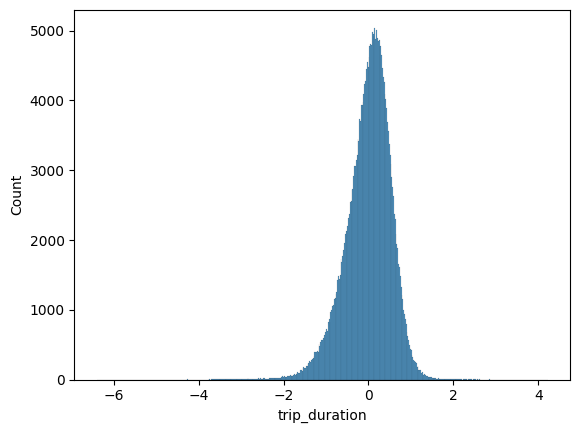

In [19]:
sns.histplot(data=residuals)

In [20]:
coef_df=pd.DataFrame({'feature': X.columns, 'importance': model.coef_}).sort_values('importance', ascending=False)

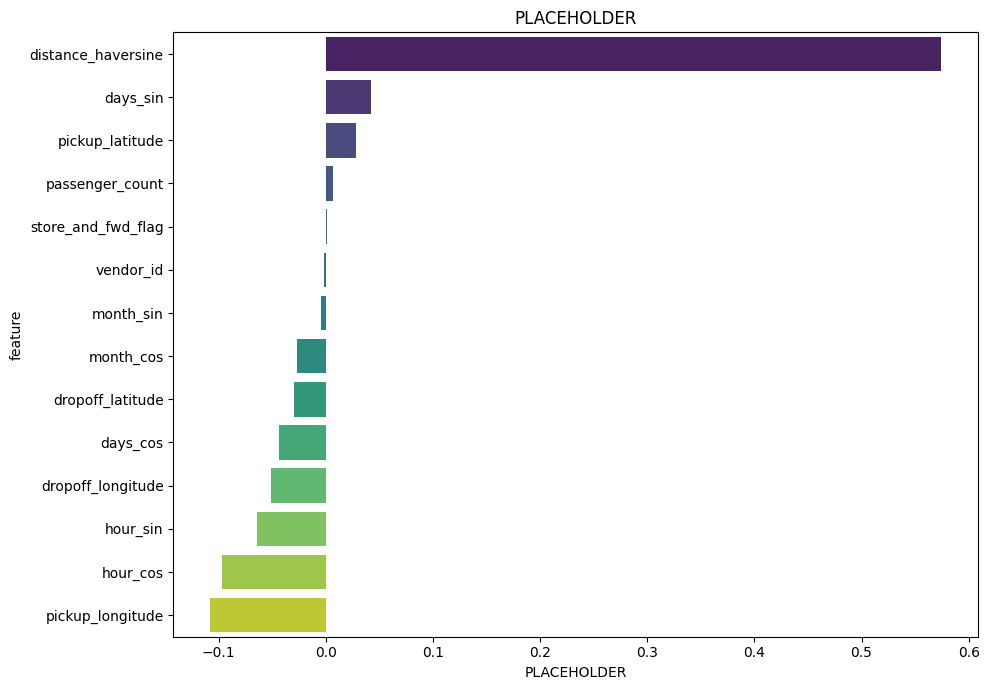

In [21]:
plt.figure(figsize=(10,7))
sns.barplot(data=coef_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('PLACEHOLDER')
plt.xlabel('PLACEHOLDER')
plt.tight_layout()
plt.show()

## XGBoost

In [22]:
xbg_feature_drop=['id','trip_duration','hour','day_of_week','month','pickup_datetime','days_sin','days_cos','month_cos','month_sin','hour_cos','hour_sin']

In [23]:
X=df.drop(columns=xbg_feature_drop)
y=df['trip_duration']

In [24]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

In [25]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

In [26]:
xgb=XGBRegressor(objective='reg:squarederror',n_estimators=1000,seed=42,early_stopping_rounds=50)
xgb.fit(X_train,y_train_log,eval_set=[(X_val,y_val_log)],verbose=100)
xgb_y_pred=xgb.predict(X_test)

[0]	validation_0-rmse:0.60612
[100]	validation_0-rmse:0.34714
[200]	validation_0-rmse:0.33925
[300]	validation_0-rmse:0.33580
[400]	validation_0-rmse:0.33367
[500]	validation_0-rmse:0.33201
[600]	validation_0-rmse:0.33148
[700]	validation_0-rmse:0.33058
[800]	validation_0-rmse:0.32997
[900]	validation_0-rmse:0.32950
[999]	validation_0-rmse:0.32910


In [27]:
print(mean_squared_error(y_test_log,xgb_y_pred))
print(root_mean_squared_error(y_test_log,xgb_y_pred))

0.10962598294718084
0.33109814700052437


<Figure size 1000x800 with 0 Axes>

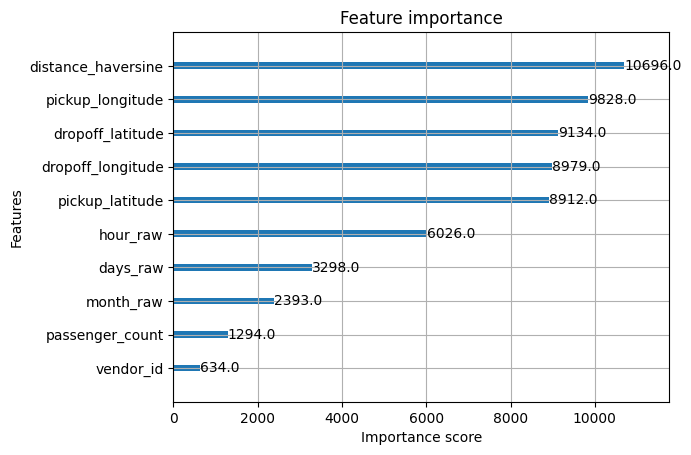

In [28]:
plt.figure(figsize=(10, 8))
plot_importance(xgb, max_num_features=10, importance_type='weight')
plt.show()

<Figure size 1000x800 with 0 Axes>

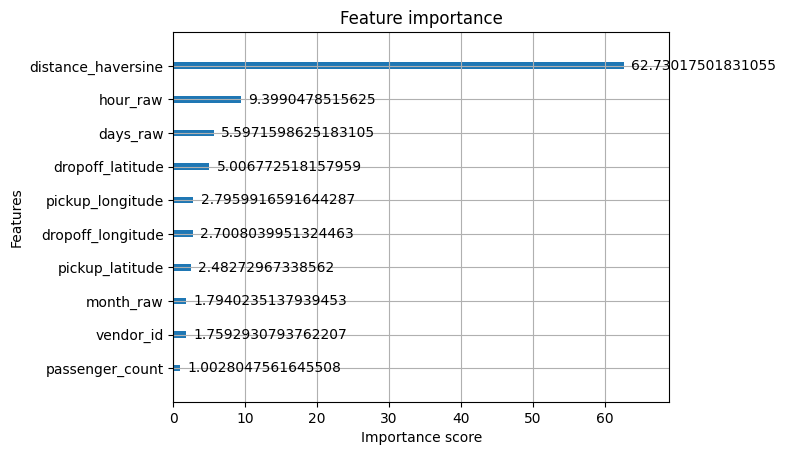

In [29]:
plt.figure(figsize=(10, 8))
plot_importance(xgb, max_num_features=10, importance_type='gain')
plt.show()

## Try other parameters

In [30]:
X_train_sample,y_train_log_sampled=resample(X_train,y_train_log,n_samples=100000,random_state=42,replace=False)

In [31]:
xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42)

In [32]:
param_dist={'max_depth': [5, 7, 9],'learning_rate':[0.01, 0.05, 0.1], 'n_estimators': [300, 500]}
xgb_cv=RandomizedSearchCV(estimator=xgb_base,param_distributions=param_dist,n_iter=5,scoring='neg_mean_squared_error',cv=3,verbose=2,n_jobs=-1,random_state=42)
xgb_cv.fit(X_train_sample,y_train_log_sampled)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [5, 7, ...], 'n_estimators': [300, 500]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 

In [33]:
xgb_cv.best_params_

{'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}

## Final parameters

In [34]:
xgb_final=XGBRegressor(objective='reg:squarederror',n_estimators=300,seed=42,max_depth=7,learning_rate=0.05)
xgb_final.fit(X_val,  y_val_log)
xgb_y_pred_final=xgb_final.predict(X_test)

In [35]:
print(mean_squared_error(y_test_log,xgb_y_pred_final))
print(root_mean_squared_error(y_test_log,xgb_y_pred_final))

0.12384825584134893
0.3519208090484973


<Figure size 1000x800 with 0 Axes>

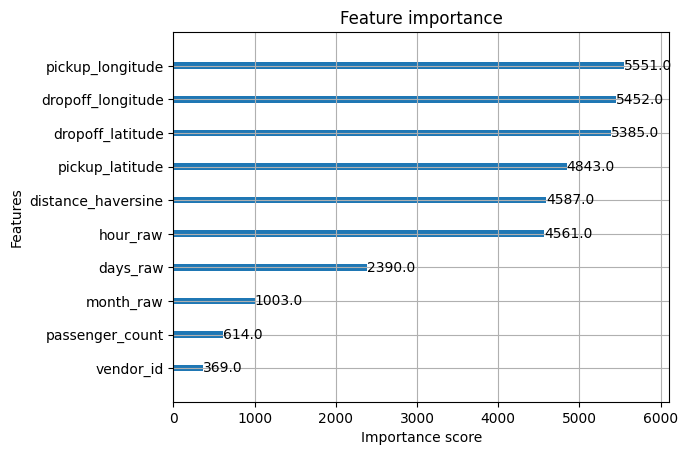

In [36]:
plt.figure(figsize=(10, 8))
plot_importance(xgb_final, max_num_features=10, importance_type='weight')
plt.show()

<Figure size 1000x800 with 0 Axes>

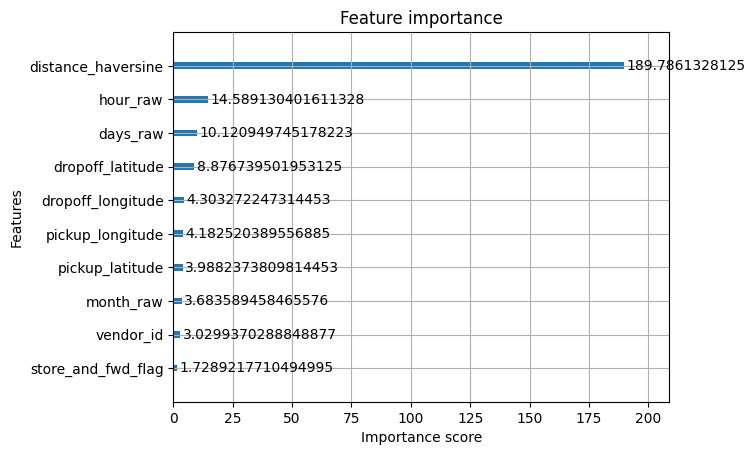

In [37]:
plt.figure(figsize=(10, 8))
plot_importance(xgb_final, max_num_features=10, importance_type='gain')
plt.show()